In [80]:
from collections import defaultdict
from scipy import stats
from scipy.stats import erlang
import numpy as np
import matplotlib.pyplot as plt

Goal: Simulate Infection from node "1" to node "6" on a graph where edges are random variables denoting the random event of infection spread

- The RVs are exponential random variables
- The RVs have rate 1
- Should I use a tick rate? 

Questions:
- What is the distribution of the minimum time overall?
- Distribution of time for each path taken?
- Distribution of paths taken?


In [2]:
class Graph(object):

    def __init__(self, edge_set, directed=False):
        self._graph = defaultdict(set)
        # Node information
        self._infected = defaultdict(lambda : False)
        self._parent = defaultdict(lambda : None)
        self._node_infect_time = defaultdict(lambda : 0) # to exploit "memoryless" exponential RV (s + t - s)
        # Graph creation
        self._directed = directed
        self.add_connections(edge_set)
        
    def add_connections(self, edge_set):
        for node1, node2, wt in edge_set:
            self.add_edge(node1,node2, wt)
            
    def add_edge(self, src, dst, wt):
        self._graph[src].add((dst, wt))
        if self._directed == False:
            self._graph[dst].add((src, wt))
            
    # Im not going to bother wiith checking src and dst in graph rn
    def simulate_gossip(self, src, dst, time_step = 0.1):
        self._infected[src] = True
        self._node_infect_time[src] = 0
        global_t = 0

        while not self._infected[dst]:
            global_t = global_t + time_step
            current_tick_infected = [key for key in self._infected.keys() if self._infected[key] == True]
            for infected in current_tick_infected:
                for new_infection, wt in self._graph[infected]:
                    if not self._infected[new_infection]:
                        infection_event_probability = wt(global_t - self._node_infect_time[infected])
                        self._infected[new_infection] = np.random.choice([True, False], p=[infection_event_probability, 1-infection_event_probability])
                        if self._infected[new_infection]:
                            self._parent[new_infection] = infected
                            self._node_infect_time[new_infection] = global_t
                            
        return global_t

    def reset_simulation(self):
        for key in self._graph.keys():
            self._infected[key] = False
            self._parent[key] = None
            self._node_infect_time[key] = 0

    def construct_path(self, dst):
        path = []
        curr_node = dst
        while curr_node is not None:
            path.append(curr_node)
            curr_node = self._parent[curr_node]
        
        return path

In [3]:
exp_t = lambda t: 1 - np.e**(-t)
edge_set = {(1,2, exp_t), (1,3, exp_t), (2,4, exp_t), (2,5, exp_t), (3,6, exp_t), (4,5, exp_t), (4,6, exp_t)}

g = Graph(edge_set)

Since lists can not be hashed I hash the sum of the the path keys since I use integers to represent nodes:

Paths and sums:

- $1 + 3 + 6 = 10$
- $1 + 2 + 4 + 6 = 13$
- $1 + 2 + 5 + 4 + 6 = 18$

So for this graph at least sum should be a fine attribute to has since it's unique for all possible paths from $1$ to $6$

In [4]:
# still going to make a dictionary for deref ease
path_ids = {
    10 : [6,3,1],
    13 : [6,4,2,1],
    18 : [6,4,5,2,1]
} 

In [5]:
g.reset_simulation()
t = g.simulate_gossip(1,6,time_step=10**(-4))
path = g.construct_path(6)
display(path)
print(t)
g.reset_simulation()

[6, 3, 1]

0.02739999999999989


In [51]:
def print_path_distribution(path_ids, paths_counts):
    for key in paths_counts.keys():
        print(f"Infection took path {path_ids[key]}: {paths_counts[key]} times")
        
def data_distribution(data, b=10):
    data = np.array(data)
    plt.hist(data, bins=b)
    staters = (np.mean(data), np.median(data), stats.mode(data))
    print(f"Mean: {np.mean(data)}, Median: {np.median(data)}, Mode: {stats.mode(data)}")
    return staters

Hypothesis:

Are we looking at a multimodal distribution?

In [7]:
def simulation_trial(g, path_ids, src, dst, t_step=10**(-6)):
    data = []
    paths = defaultdict(lambda : 0) # counting unique paths taken
    time_per_path = defaultdict(list)
    for i in range(1000):
        t = g.simulate_gossip(src,dst,time_step=t_step)
        path = g.construct_path(dst)
        path_id = sum(path)
        paths[path_id] = paths[path_id] + 1
        time_per_path[path_id].append(t)
        data.append(t)
        g.reset_simulation()
        
    return data, paths, time_per_path

In [8]:
list_of_paths = []
list_of_data = []
list_of_time_per_path = []
for i in range(20):
    (a,b,c) = simulation_trial(g, path_ids, 1, 6)
    list_of_data.append(a)
    list_of_paths.append(b)
    list_of_time_per_path.append(c)

Simulation takes approximately 20 minutes to run the twenty trials at the current tick rate

In [9]:
p1_data = []
p2_data = []
p3_data = []
for trial in list_of_paths:
    p1_data.append(trial[10]/1000)
    p2_data.append(trial[13]/1000)
    p3_data.append(trial[18]/1000)
    
p1_data = np.array(p1_data)
p2_data = np.array(p2_data) 
p3_data = np.array(p3_data) 
    
print(f"Path {path_ids[10]} mean prob, stdev: {p1_data.mean()} +/- {p1_data.std()}")
print(f"Path {path_ids[13]} mean prob, stdev: {p2_data.mean()} +/- {p2_data.std()}")
print(f"Path {path_ids[18]} mean prob, stdev: {p3_data.mean()} +/- {p3_data.std()}")

Path [6, 3, 1] mean prob, stdev: 0.7974499999999999 +/- 0.015081362670528127
Path [6, 4, 2, 1] mean prob, stdev: 0.1849 +/- 0.01607762420259909
Path [6, 4, 5, 2, 1] mean prob, stdev: 0.017650000000000006 +/- 0.0041143043154341415


So I'll guess probabilities around ~0.8, ~0.19, and ~0.01, super off from my original hypothesis, probabily because the way my og hypothesis went presumed uniform dist

Mean: 0.0023528663000000195, Median: 0.002316999999999983, Mode: ModeResult(mode=np.float64(0.002375999999999991), count=np.int64(20))


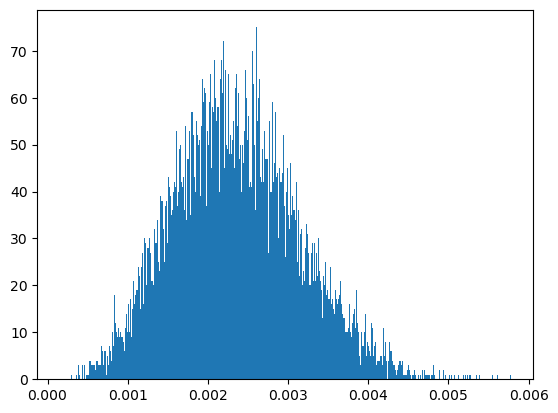

In [22]:
data_comp = np.array(list_of_data).flatten()
data_distribution(data_comp, b=1000)

In [11]:
short_path = [] 
med_path = []
long_path = []
for trial in list_of_time_per_path:
    short_path = short_path + trial[10]
    med_path = med_path + trial[13]
    long_path = long_path + trial[18]
    
short_path = np.array(short_path)
med_path = np.array(med_path)
long_path = np.array(long_path)

Mean: 0.0022768962317386812, Median: 0.002231999999999972, Mode: ModeResult(mode=np.float64(0.0016489999999999606), count=np.int64(16))


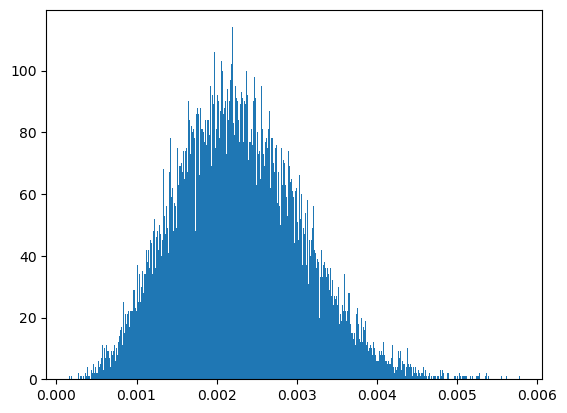

In [19]:
data_distribution(short_path, b=500)

Mean: 0.002626862358031406, Median: 0.0025900000000000194, Mode: ModeResult(mode=np.float64(0.0023729999999999906), count=np.int64(8))


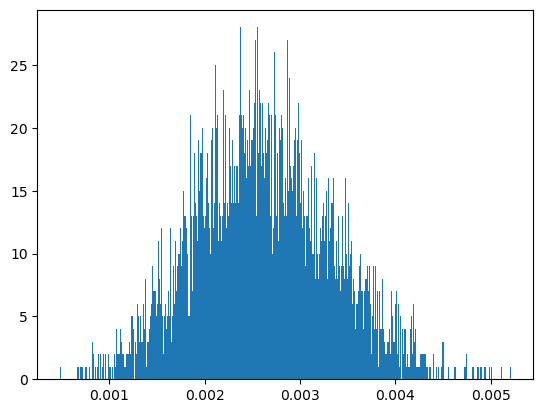

In [20]:
data_distribution(med_path, b=500)

Mean: 0.0029149320113315124, Median: 0.0028910000000000593, Mode: ModeResult(mode=np.float64(0.0029670000000000694), count=np.int64(3))


(np.float64(0.0029149320113315124),
 np.float64(0.0028910000000000593),
 ModeResult(mode=np.float64(0.0029670000000000694), count=np.int64(3)))

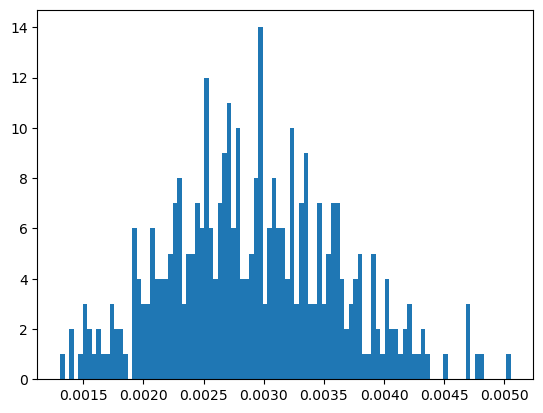

In [87]:
data_distribution(long_path, b=100)

Mean: 0.0023528663000000195, Median: 0.002316999999999983, Mode: ModeResult(mode=np.float64(0.002375999999999991), count=np.int64(20))
Mean: 0.0022923453898606736, Median: 0.002249499999999974, Mode: ModeResult(mode=np.float64(0.0018999999999999395), count=np.int64(17))


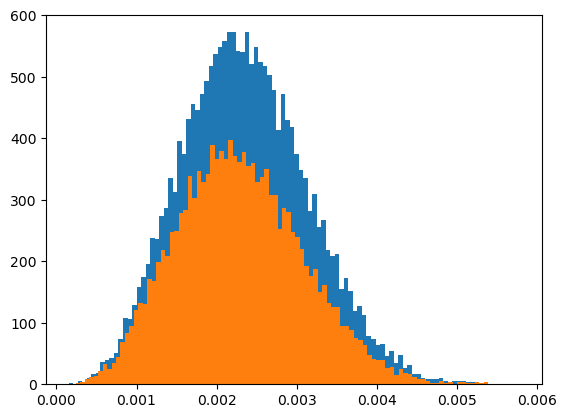

In [57]:
sp = np.random.choice(short_path, int(0.8*len(short_path)), replace=False)
mp = np.random.choice(med_path, int(0.19*len(med_path)), replace=False)
lp = np.random.choice(long_path, int(0.09*len(long_path)), replace=False)
pdf_recreation = np.append(np.append(sp, mp),lp)
stats1 = data_distribution(data_comp, b=100)
stats2 = data_distribution(pdf_recreation, b=100)

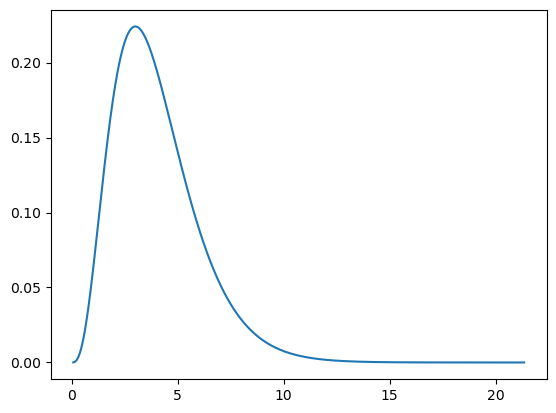

Given $k=$ shape, or number of exponential rvs and $\lambda=$ rate of exponential RVs we have
`erlang.pdf(x, k, scale=1/lambda)`

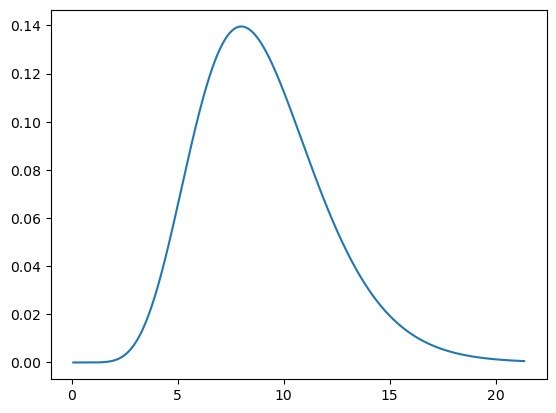

In [96]:
x = np.linspace(erlang.ppf(10**(-6),4), erlang.ppf(1-10**(-6),4), 1000)
plt.plot(x, erlang.pdf(x,9,scale=1))